<a href="https://colab.research.google.com/github/rizki-ap/Gunshot-Locator/blob/main/FFT_wav.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First, we need to import the necessary libraries to handle the audio file and plotting.

In [2]:
import requests
from scipy.io import wavfile
import matplotlib.pyplot as plt
import numpy as np
import os

Downloaded to downloaded_audio.wav


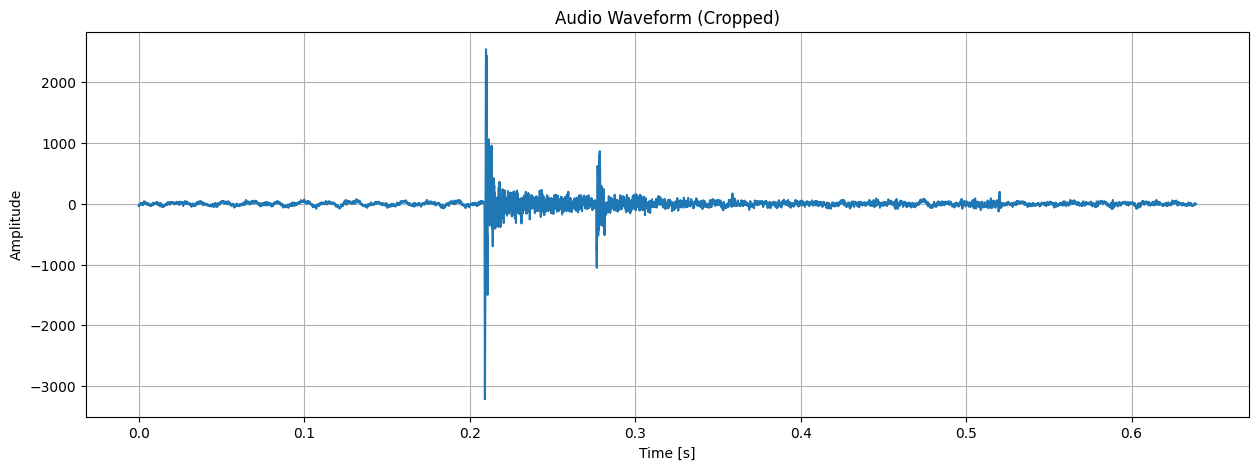

In [17]:
# Replace this with the direct URL to your .wav file on GitHub
wav_file_url = 'https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/glock3_ch0.wav'
local_filename = 'downloaded_audio.wav'

# Check if the URL is provided
if wav_file_url == 'YOUR_GITHUB_RAW_WAV_FILE_URL_HERE':
    print("Please provide the direct URL to your WAV file from GitHub in the 'wav_file_url' variable.")
else:
    try:
        # Download the WAV file
        print(f"Downloading {wav_file_url}...")
        response = requests.get(wav_file_url)
        response.raise_for_status() # Raise an exception for HTTP errors

        with open(local_filename, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded to {local_filename}")

        # Read the WAV file
        samplerate, data = wavfile.read(local_filename)

        # If stereo, take one channel for plotting
        if data.ndim > 1:
            data = data[:, 0] # Take the first channel

        # Create a time array for the x-axis for the (possibly cropped) data
        time = np.linspace(0., len(data) / samplerate, len(data))

        # Plot the waveform
        plt.figure(figsize=(15, 5))
        plt.plot(time, data)
        plt.xlabel("Time [s]")
        plt.ylabel("Amplitude")
        plt.title("Audio Waveform")
        plt.grid(True)
        plt.show()

        # Optional: Remove the downloaded file after processing
        # os.remove(local_filename)
        # print(f"Removed temporary file: {local_filename}")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
    except FileNotFoundError:
        print(f"Error: The file '{local_filename}' was not found after download.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Now, let's perform a Fast Fourier Transform (FFT) on the audio data to analyze its frequency content.

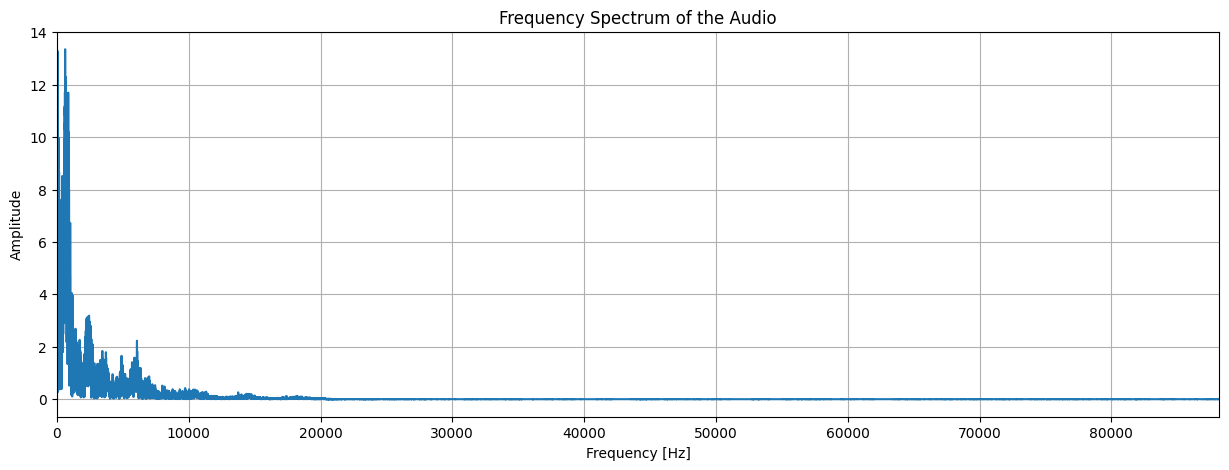

In [8]:
from scipy.fft import fft, fftfreq

# Perform FFT
N = len(data) # Number of sample points
T = 1.0 / samplerate # Sample spacing
N_fft_block = 2048 # Desired FFT block size

yf = fft(data)
xf = fftfreq(N, T)[:N//2]

# Plot the frequency spectrum
plt.figure(figsize=(15, 5))
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum of the Audio")
plt.grid(True)
plt.xlim(0, samplerate / 2) # Show frequencies up to Nyquist frequency
plt.show()

Now, let's perform the FFT on the newly cropped audio data to see its frequency spectrum.

Maximum amplitude: -3215 (at index 36893)
Time at maximum amplitude: 0.2091 seconds


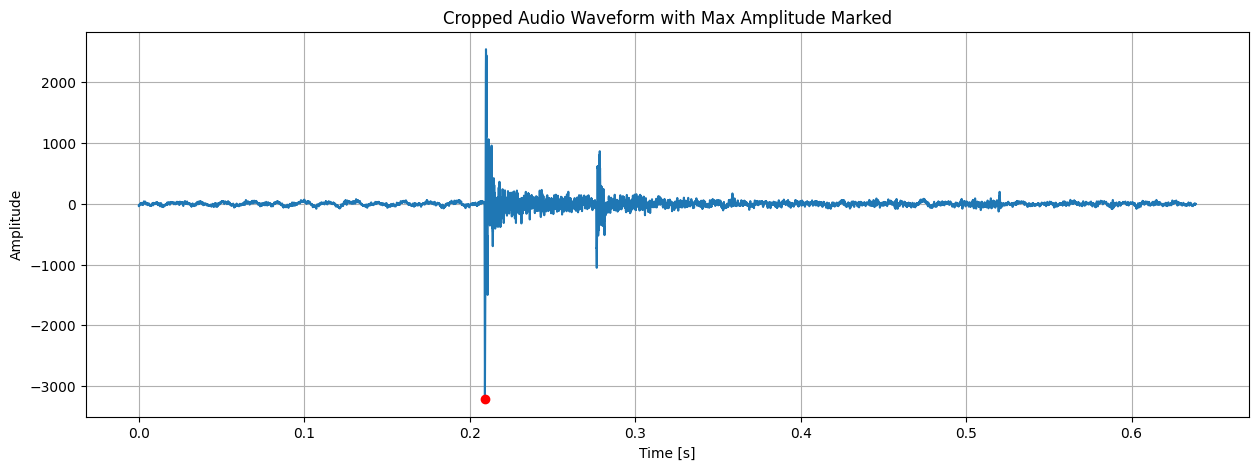

In [55]:
# Find the index of the maximum amplitude in the cropped data
max_amplitude_index = np.argmax(np.abs(data))

# Get the maximum amplitude value
max_amplitude_value = data[max_amplitude_index]

# Convert the index to time
time_at_max_amplitude = time[max_amplitude_index]

print(f"Maximum amplitude: {max_amplitude_value} (at index {max_amplitude_index})")
print(f"Time at maximum amplitude: {time_at_max_amplitude:.4f} seconds")

# Optionally, visualize this point on the cropped waveform plot
plt.figure(figsize=(15, 5))
plt.plot(time, data)
plt.plot(time_at_max_amplitude, max_amplitude_value, 'ro') # Mark the point in red
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Cropped Audio Waveform with Max Amplitude Marked")
plt.grid(True)
plt.show()

New audio data cropped from 34845 to 296989 samples.


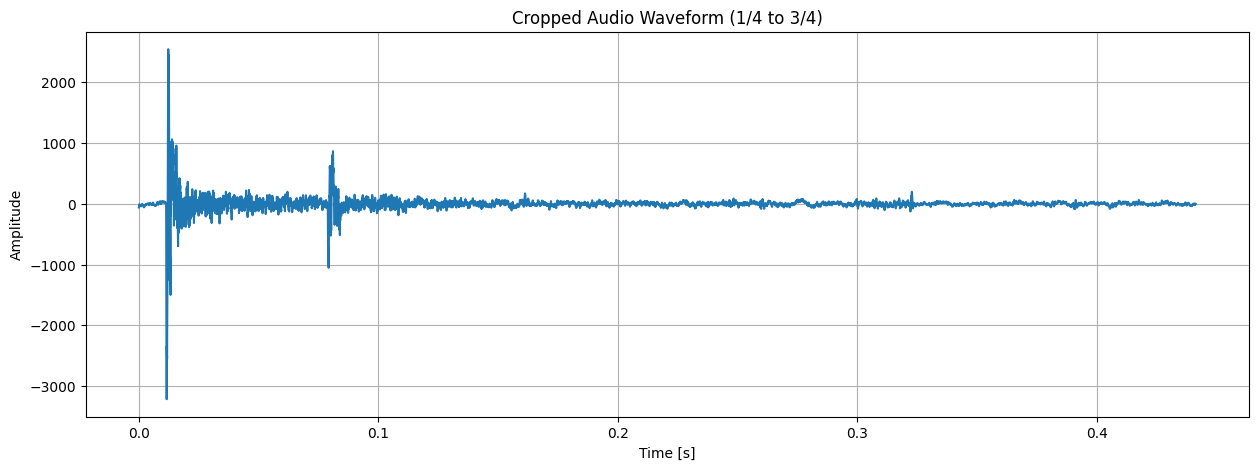

In [67]:
# Create a cropped version of the audio data
cropped_total_samples = len(data)
cropped_start_index = int(max_amplitude_index - (N_fft_block/8) )
cropped_end_index = int(cropped_start_index + N_fft_block * 16)

cropped_data = data[cropped_start_index:cropped_end_index]

print(f"New audio data cropped from {cropped_start_index} to {cropped_end_index} samples.")

# Create a time array for the cropped data
cropped_time = np.linspace(0., len(cropped_data) / samplerate, len(cropped_data))

# Plot the cropped waveform
plt.figure(figsize=(15, 5))
plt.plot(cropped_time, cropped_data)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Cropped Audio Waveform (1/4 to 3/4)")
plt.grid(True)
plt.show()

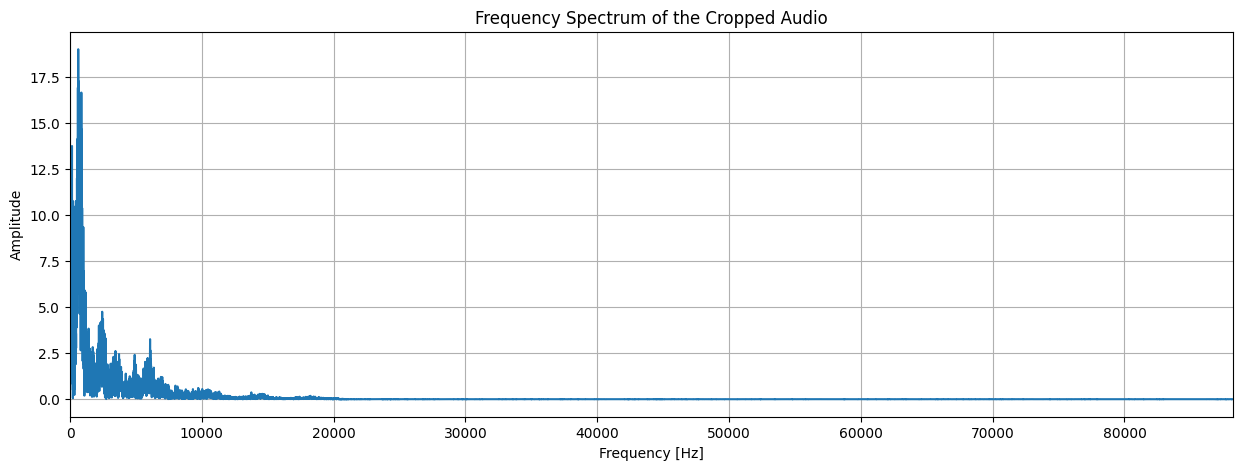

In [68]:
from scipy.fft import fft, fftfreq

# Perform FFT on the cropped data
N_cropped = len(cropped_data) # Number of sample points for cropped data
T_cropped = 1.0 / samplerate # Sample spacing is the same

yf_cropped = fft(cropped_data)
xf_cropped = fftfreq(N_cropped, T_cropped)[:N_cropped//2]

# Plot the frequency spectrum of the cropped data
plt.figure(figsize=(15, 5))
plt.plot(xf_cropped, 2.0/N_cropped * np.abs(yf_cropped[0:N_cropped//2]))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum of the Cropped Audio")
plt.grid(True)
plt.xlim(0, samplerate / 2) # Show frequencies up to Nyquist frequency
plt.show()

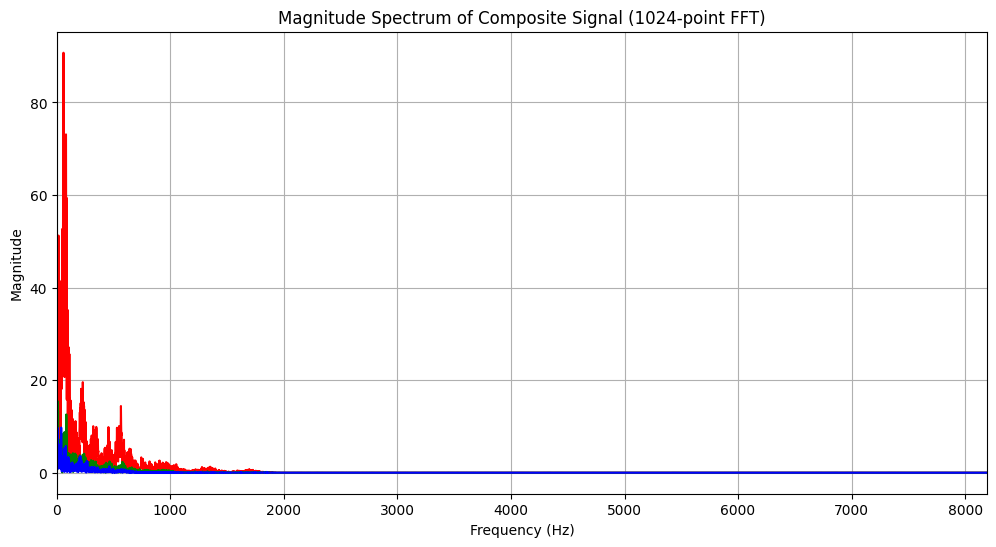

In [71]:
# Perform FFT with a 1024-point block
N_fft = 1024*16 # Desired FFT block size

# Use only the first N_fft_block samples of the composite signal
signal_for_fft_1 = cropped_data[:N_fft]
signal_for_fft_2 = cropped_data[N_fft:2*N_fft]
signal_for_fft_3 = cropped_data[2*N_fft:3*N_fft]

# Perform FFT #1
yf_1 = np.fft.fft(signal_for_fft_1)
x_axis_1 = np.fft.fftfreq(N_fft, 1 / N_fft)

# Take only the positive frequency part of the spectrum
half_N = N_fft // 2
freqs_1 = x_axis_1[:half_N]
magnitude_1 = 2.0 / N_fft * np.abs(yf_1[0:half_N])

# Perform FFT #2
yf_2 = np.fft.fft(signal_for_fft_2)
x_axis_2 = np.fft.fftfreq(N_fft, 1 / N_fft)

# Take only the positive frequency part of the spectrum
freqs_2 = x_axis_2[:half_N]
magnitude_2 = 2.0 / N_fft * np.abs(yf_2[0:half_N])

# Perform FFT #3
yf_3 = np.fft.fft(signal_for_fft_3)
x_axis_3 = np.fft.fftfreq(N_fft, 1 / N_fft)

# Take only the positive frequency part of the spectrum
freqs_3 = x_axis_3[:half_N]
magnitude_3 = 2.0 / N_fft * np.abs(yf_3[0:half_N])

# Plot the magnitude spectrum
plt.figure(figsize=(12, 6))
plt.plot(freqs_1, magnitude_1, 'r')
plt.plot(freqs_2, magnitude_2, 'g')
plt.plot(freqs_3, magnitude_3, 'b')
plt.title('Magnitude Spectrum of Composite Signal (1024-point FFT)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, N_fft / 2) # Limit x-axis to Nyquist frequency
plt.show()